# Lab 2.07 - Univariate Analysis

## Exercise 7 - Australian Athletes (ais)

Import all necessary Python libraries and load the AIS dataset from lab exercise 1.01. Also include the code for setting the index and conversion to categorical variables!

In [7]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

ais = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/refs/heads/main/data/ais.csv')
#strings are always qualitative variables
print(ais.sex.describe())
ais.sex = ais.sex.astype('category')
#there's not really a difference.
print(ais.sex.describe())

print(ais.sex.unique())

mf = CategoricalDtype(categories=['m', 'f'], ordered=True)
ais.sex = ais.sex.astype(mf)
print(ais.sex.describe())

print(ais.sport.describe())
ais.sport = ais.sport.astype('category')
print(ais.sport.describe())

ais.set_index('id')
ais.info()

count     202
unique      2
top         m
freq      102
Name: sex, dtype: object
count     202
unique      2
top         m
freq      102
Name: sex, dtype: object
['f', 'm']
Categories (2, str): ['f', 'm']
count     202
unique      2
top         m
freq      102
Name: sex, dtype: object
count     202
unique     10
top       Row
freq       37
Name: sport, dtype: object
count     202
unique     10
top       Row
freq       37
Name: sport, dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   id      202 non-null    int64   
 1   rcc     202 non-null    float64 
 2   wcc     202 non-null    float64 
 3   hc      202 non-null    float64 
 4   hg      202 non-null    float64 
 5   ferr    202 non-null    int64   
 6   bmi     202 non-null    float64 
 7   ssf     202 non-null    float64 
 8   pcBfat  202 non-null    float64 
 9   lbm     202 non-null    float64

Use an appropriate chart type to visualise the following variables. Are several chart types suitable? Make one of each! Note how some graphs nevertheless give a better insight into the data than other types of graphs.

- `sex`
- `sport`
- `ht` (show this also divided by `sex` and by `sport`.)

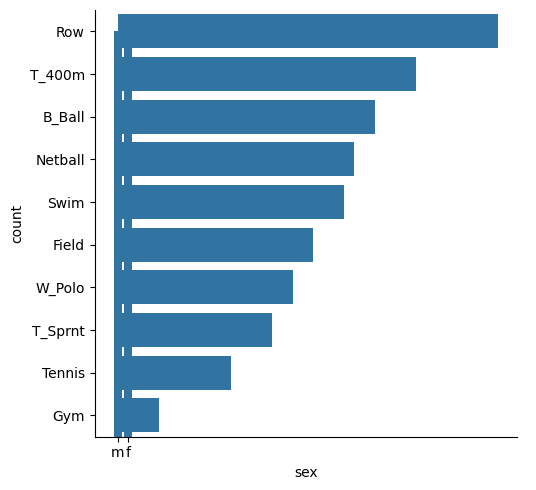

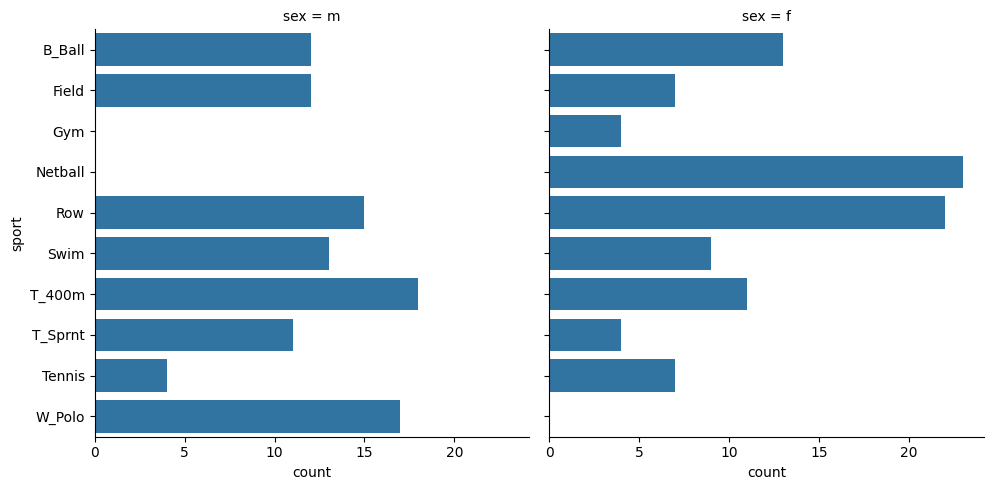

In [ ]:
sns.catplot(data=ais, x='sex', kind='count')


sns.countplot(data=ais, y='sport', order=ais.sport.value_counts().index)


sns.catplot(data=ais, kind='count', col='sex', y='sport')


sns.boxplot(data=ais, x='ht', y='sport')


sns.kdeplot(data=ais, x='ht', hue='sex')

Select the following subsets from the dataset and calculate for each the appropriate measures of central tendency (and, when possible, dispersion) of the variables `ht` and `sex`:

1. the rowers
2. the rowers, netball and tennis players together
3. the female basketball players and rowers together

In [30]:
rowers = ais[ais.sport == "Row"]
print(rowers.head())

rnt = ais[(ais.sport == "Row") | (ais.sport == "Netball") | (ais.sport == "Tennis")]
print(rnt.head())

whatever = ais[(ais.sex == "f") & ( (ais.sport == "Row") | (ais.sport == "Netball"))]

print(rowers.sex.value_counts())
print(whatever.sex.value_counts())

rowers.ht.describe()

    id   rcc  wcc    hc    hg  ferr    bmi    ssf  pcBfat    lbm     ht    wt  \
13  14  4.26  6.2  41.0  13.9    48  25.44   90.2   17.71  66.24  177.9  80.5   
14  15  4.63  6.0  43.7  14.7    30  22.63   97.2   18.77  57.92  177.5  71.3   
15  16  4.36  5.8  40.3  13.3    29  21.86   99.9   19.83  56.52  179.6  70.5   
16  17  3.91  7.3  37.6  12.9    43  22.27  125.9   25.16  54.78  181.3  73.2   
17  18  4.51  8.3  43.7  14.7    34  21.27   69.9   18.04  56.31  179.7  68.7   

   sex sport  
13   f   Row  
14   f   Row  
15   f   Row  
16   f   Row  
17   f   Row  
    id   rcc  wcc    hc    hg  ferr    bmi    ssf  pcBfat    lbm     ht    wt  \
13  14  4.26  6.2  41.0  13.9    48  25.44   90.2   17.71  66.24  177.9  80.5   
14  15  4.63  6.0  43.7  14.7    30  22.63   97.2   18.77  57.92  177.5  71.3   
15  16  4.36  5.8  40.3  13.3    29  21.86   99.9   19.83  56.52  179.6  70.5   
16  17  3.91  7.3  37.6  12.9    43  22.27  125.9   25.16  54.78  181.3  73.2   
17  18  4.51  8.3 

count     37.000000
mean     182.375676
std        7.798376
min      156.000000
25%      179.300000
50%      181.800000
75%      186.300000
max      198.000000
Name: ht, dtype: float64

## Check your answers

As a check, here are the results of the last question. First the frequencies and mode of the variable `sex`:

|           | Selection 1 | Selection 2 | Selection 3 |
| :-------- | :---------- | :---------- | :---------- |
| **f**     | 22          | 52          | 35          |
| **m**     | 15          | 19          | 0           |
| **mode**  | f           | f           | f           |

Then the relevant measures for central tendency and dispersion for `ht` (max. 3 decimal places):

| Statistic  | Selection 1 | Selection 2 | Selection 3 |
| :--------- | :---------- | :---------- | :---------- |
| mean       | 182.376     | 179.066     | 180.126     |
| stdev      | 7.798       | 7.936       | 7.144       |
| min        | 156         | 156         | 156         |
| Q1         | 179.3       | 174.25      | 177.4       |
| median     | 181.8       | 179.5       | 179.7       |
| Q3         | 186.3       | 183.4       | 184.65      |
| max        | 198         | 198         | 195.9       |
| IQR        | 7           | 9.15        | 7.250       |